# Confusion Matrix Analysis for Continual Learning Methods

This notebook analyzes the predictions of different continual learning methods (oEWC, DERpp, EFC) on MNIST dataset, comparing both Task-Incremental Learning (TaskIL) and Class-Incremental Learning (ClassIL) scenarios.

**Methods analyzed:**
- **oEWC**: Online Elastic Weight Consolidation
- **DERpp**: Dark Experience Replay++
- **EFC**: Equilibrium Fisher Control

In [17]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from omegaconf import OmegaConf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm

# Add project root to path
project_root = Path('.').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import project modules
from networks.oEWC_network import oEWC_network
from networks.DER_network import DERpp_network
from networks.EFC_network import EFC_network
from src.dataloaders_2 import TaskILMNIST, ClassILMNIST5Task

# Plotting setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DEVICE = 'cpu' #'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Configuration Definitions

Define configurations for each method based on the best hyperparameters from the final configs.

In [18]:
# Base configuration shared across methods
def get_base_config(setting: str, seed: int = 0):
    """Create base configuration for MNIST experiments."""
    
    # Determine if TaskIL or ClassIL
    is_class_il = 'ClassIL' in setting
    
    config = {
        'setting': setting,
        'dataset': 'MNIST',
        'device': DEVICE,
        'seed': seed,
        'batch_size': 256,
        'num_workers': 0,
        'epochs': 20,
        'optimizer': 'Adam',
        'scheduler': 'CosineAnnealingLR',
        'cnn_pretrained': True,
        'use_cnn_encoder': False,
        'flatten_imgs': True,
        'num_tasks': 5,
        'classes_per_task': 2,
        'output_dir': './outputs',
        'save': False,
        'loss_fn': 'ce',
    }
    return config


def get_oewc_config(setting: str, seed: int = 0):
    """oEWC configuration from final_configs/oewc/."""
    config = get_base_config(setting, seed)
    config.update({
        'method': 'oewc',
        'layer_size': 100,
        'lr': 0.001,
        'layers': [784, 100, 100, 10],
        # oEWC-specific parameters
        'importance_ewc': 10.0,
        'gamma_oewc': 0.95,
        'normalize_fisher': True,
    })
    return OmegaConf.create(config)


def get_derpp_config(setting: str, seed: int = 0):
    """DERpp configuration from final_configs/derpp/."""
    config = get_base_config(setting, seed)
    
    # DERpp uses different lr for taskIL vs classIL
    is_class_il = 'ClassIL' in setting
    lr = 0.001 if is_class_il else 0.0001
    
    config.update({
        'method': 'derpp',
        'layer_size': 100,
        'lr': lr,
        'layers': [784, 100, 100, 10],
        # DERpp-specific parameters
        'der_alpha': 0.5,
        'der_beta': 0.5,
    })
    return OmegaConf.create(config)


def get_efc_config(setting: str, seed: int = 0):
    """EFC configuration from final_configs/efc/."""
    config = get_base_config(setting, seed)
    
    is_class_il = 'ClassIL' in setting
    
    # EFC uses different layer_size and params for ClassIL vs TaskIL
    if is_class_il:
        layer_size = 1000
        beta_efc = 1.0
        target_lr = 0.01
    else:
        layer_size = 100
        beta_efc = 0.1
        target_lr = 0.1
    
    config.update({
        'method': 'efc',
        'layer_size': layer_size,
        'lr': 1e-4,
        'layers': [784, layer_size, layer_size, 10],
        # EFC-specific parameters
        'beta_efc': beta_efc,
        'target_lr': target_lr,
        'alpha_di': 0.0017,
        'alpha_I': 0.0017,
        'tau': 0.032,
        'eps': 1e-4,
        'dt_di': 0.02,
        'time_constant_ratio': 0.2,
        'tmax_di': 500,
        'k_p': 2.0,
        'mode': 'di',
    })
    return OmegaConf.create(config)


# Configuration factory
CONFIG_FACTORY = {
    'oewc': get_oewc_config,
    'derpp': get_derpp_config,
    'efc': get_efc_config,
}

# Model factory
MODEL_FACTORY = {
    'oewc': oEWC_network,
    'derpp': DERpp_network,
    'efc': EFC_network,
}

## 2. Training and Evaluation Helpers

In [19]:
def set_seed(seed: int):
    """Set random seeds for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)


def train_model(model, tasks_dataloaders, config, verbose: bool = True):
    """
    Train a continual learning model through all tasks.
    Matches the training flow from src/trainers.py TrainerCL.
    """
    device = torch.device(config.device)
    model.to(device)
    
    num_tasks = len(tasks_dataloaders)
    
    for task_id in range(num_tasks):
        train_loader, test_loader = tasks_dataloaders[task_id]
        
        # Set task for the model
        model.task_id = task_id
        
        # Mark first task as done after task 0
        if task_id > 0 and hasattr(model, '_first_task'):
            model._first_task = False
        
        # Setup fresh optimizer for each task (like the real trainer does)
        if config.optimizer == 'Adam':
            optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
        else:
            optimizer = torch.optim.SGD(model.parameters(), lr=config.lr)
        
        if verbose:
            print(f"Training Task {task_id + 1}/{num_tasks}")
        
        # Training loop
        pbar = tqdm(range(config.epochs), disable=not verbose, desc=f"Task {task_id}")
        for epoch in pbar:
            model.train()
            epoch_loss = 0.0
            n_batches = 0
            
            for X, y in train_loader:
                X = X.to(device)
                y = y.to(device)
                
                # Forward pass
                y_hat = model(X)
                
                # Calculate loss
                loss = model.calculate_loss(y_hat, y)
                
                # Backward pass (matching trainer order: zero_grad, backward, step)
                optimizer.zero_grad()
                model.backward(y)
                optimizer.step()
                
                epoch_loss += loss.item()
                n_batches += 1
            
            avg_loss = epoch_loss / n_batches
            pbar.set_postfix({'loss': f'{avg_loss:.4f}'})
        
        # End of task: update Fisher information / replay buffer
        if hasattr(model, 'complete_task'):
            model.complete_task(train_loader)
        
        # Evaluate after each task
        if verbose:
            acc = evaluate_model(model, test_loader, config, device)
            print(f"  Task {task_id} test accuracy: {acc:.2f}%")
    
    return model


@torch.no_grad()
def evaluate_model(model, test_loader, config, device=None):
    """Evaluate model accuracy on test set."""
    if device is None:
        device = torch.device(config.device)
    
    model.eval()
    correct = 0
    total = 0
    
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)
        
        y_hat = model(X)
        preds = y_hat.argmax(dim=1)
        labels = y.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return 100.0 * correct / total


@torch.no_grad()
def get_predictions(model, test_loader, config, device=None):
    """
    Collect all predictions and true labels from the test set.
    """
    if device is None:
        device = torch.device(config.device)
    
    model.eval()
    all_preds = []
    all_labels = []
    
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)
        
        y_hat = model(X)
        preds = y_hat.argmax(dim=1).cpu().numpy()
        labels = y.argmax(dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels)
    
    return np.array(all_preds), np.array(all_labels)

## 3. Confusion Matrix Visualization

In [20]:
def plot_confusion_matrix(y_true, y_pred, title: str, ax=None, normalize: bool = True):
    """
    Plot a confusion matrix.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        title: Plot title
        ax: Matplotlib axes (optional)
        normalize: If True, normalize by row (true label)
    """
    # Get unique labels
    labels = np.unique(np.concatenate([y_true, y_pred]))
    labels = sorted(labels)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        fmt = '.2f'
    else:
        fmt = 'd'
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)
    
    return ax


def plot_comparison_confusion_matrices(results: dict, setting: str, normalize: bool = True):
    """
    Plot confusion matrices for all methods side by side.
    
    Args:
        results: Dict mapping method name to (y_true, y_pred, accuracy)
        setting: 'ClassIL' or 'TaskIL'
        normalize: If True, normalize confusion matrices
    """
    n_methods = len(results)
    fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 5))
    
    if n_methods == 1:
        axes = [axes]
    
    for ax, (method_name, (y_true, y_pred, accuracy)) in zip(axes, results.items()):
        title = f"{method_name}\n{setting} MNIST\nAccuracy: {accuracy:.2f}%"
        plot_confusion_matrix(y_true, y_pred, title, ax=ax, normalize=normalize)
    
    plt.tight_layout()
    return fig


def analyze_confusion_patterns(y_true, y_pred, method_name: str):
    """
    Analyze and print interesting patterns from the confusion matrix.
    """
    labels = np.unique(np.concatenate([y_true, y_pred]))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    print(f"\n{'='*50}")
    print(f"Analysis for {method_name}")
    print(f"{'='*50}")
    
    # Per-class accuracy
    per_class_acc = np.diag(cm) / cm.sum(axis=1)
    print(f"\nPer-class accuracy:")
    for label, acc in zip(labels, per_class_acc):
        print(f"  Class {label}: {acc*100:.1f}%")
    
    # Most confused pairs
    print(f"\nMost common misclassifications:")
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    
    # Get top 5 confusion pairs
    flat_indices = np.argsort(cm_no_diag.flatten())[::-1][:5]
    for idx in flat_indices:
        i, j = divmod(idx, len(labels))
        if cm_no_diag[i, j] > 0:
            print(f"  {labels[i]} -> {labels[j]}: {cm_no_diag[i, j]} samples")
    
    # Task-wise analysis (for 5 tasks with 2 classes each)
    print(f"\nPer-task accuracy (assuming 2 classes per task):")
    for task_id in range(5):
        task_classes = [task_id * 2, task_id * 2 + 1]
        task_mask = np.isin(y_true, task_classes)
        if task_mask.sum() > 0:
            task_acc = (y_true[task_mask] == y_pred[task_mask]).mean()
            print(f"  Task {task_id} (classes {task_classes}): {task_acc*100:.1f}%")

## 4. Class-Incremental Learning (ClassIL) Analysis

In ClassIL, the model must distinguish between all classes seen so far without knowing which task a sample belongs to. This is more challenging than TaskIL.

In [ ]:
# Train and evaluate all methods on ClassIL MNIST
SETTING_CLASSIL = 'ClassILMNIST5Task'
SEED = 0

# IMPORTANT: Create ALL dataloaders FIRST before any model creation
# This avoids the torch.set_default_device conflict
print("Creating dataloaders for all methods...")
all_classil_dataloaders = {}
for method_name in ['oewc', 'derpp', 'efc']:
    config = CONFIG_FACTORY[method_name](SETTING_CLASSIL, seed=SEED)
    all_classil_dataloaders[method_name] = ClassILMNIST5Task(config).get_all_tasks_dataloaders()
print("Dataloaders created.\n")

classil_results = {}
classil_models = {}

for method_name in ['efc']:
    print(f"\n{'='*60}")
    print(f"Training {method_name.upper()} on ClassIL MNIST")
    print(f"{'='*60}")
    
    # Get configuration
    config = CONFIG_FACTORY[method_name](SETTING_CLASSIL, seed=SEED)
    
    # Set seed for reproducibility
    set_seed(config.seed)
    
    # Get pre-created dataloaders
    tasks_dataloaders = all_classil_dataloaders[method_name]
    
    # Initialize model
    model = MODEL_FACTORY[method_name](config)
    
    # Train model
    model = train_model(model, tasks_dataloaders, config, verbose=True)
    
    # Set to final task for full evaluation
    model.task_id = config.num_tasks - 1
    
    # Get final test loader (cumulative test set)
    _, final_test_loader = tasks_dataloaders[-1]
    
    # Get predictions
    device = torch.device(config.device)
    y_pred, y_true = get_predictions(model, final_test_loader, config, device)
    accuracy = 100.0 * (y_pred == y_true).mean()
    
    print(f"\n{method_name.upper()} Final Accuracy: {accuracy:.2f}%")
    
    classil_results[method_name.upper()] = (y_true, y_pred, accuracy)
    classil_models[method_name] = model

Creating dataloaders for all methods...
DataLoader using device: cpu
DataLoader using device: cpu
DataLoader using device: cpu
Dataloaders created.


Training EFC on ClassIL MNIST
Training Task 1/5


Fisher: 100%|██████████| 50/50 [00:24<00:00,  2.06it/s]


  Task 0 test accuracy: 99.91%
Training Task 2/5


Fisher: 100%|██████████| 48/48 [00:21<00:00,  2.25it/s]


  Task 1 test accuracy: 50.25%
Training Task 3/5


Task 2:   0%|          | 0/20 [00:00<?, ?it/s]

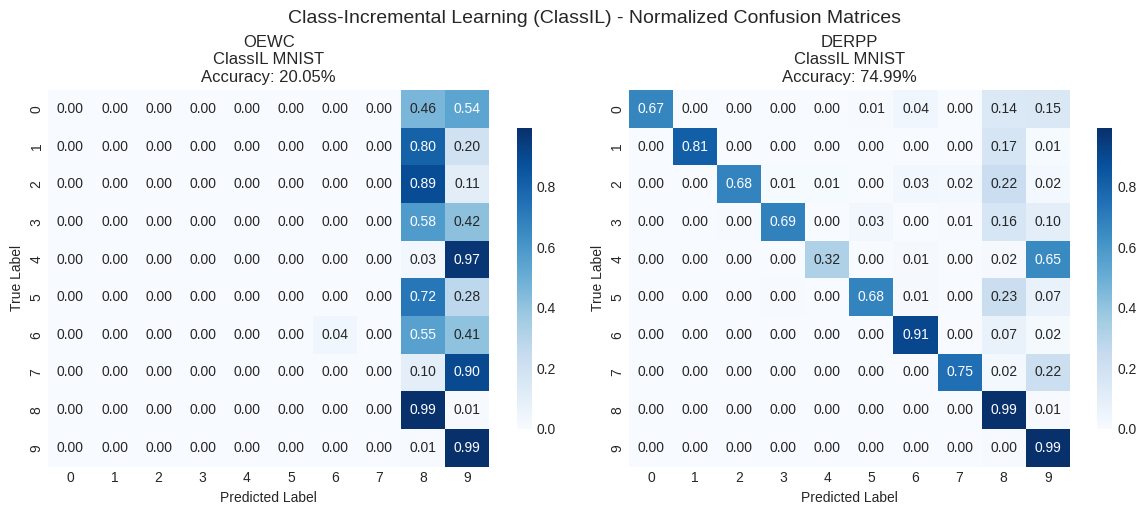

In [12]:
# Plot ClassIL confusion matrices
fig = plot_comparison_confusion_matrices(classil_results, 'ClassIL', normalize=True)
fig.suptitle('Class-Incremental Learning (ClassIL) - Normalized Confusion Matrices', 
             fontsize=14, y=1.02)
plt.savefig('classil_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Detailed analysis for each ClassIL method
for method_name, (y_true, y_pred, accuracy) in classil_results.items():
    analyze_confusion_patterns(y_true, y_pred, f"{method_name} (ClassIL)")


Analysis for OEWC (ClassIL)

Per-class accuracy:
  Class 0: 0.0%
  Class 1: 0.0%
  Class 2: 0.0%
  Class 3: 0.0%
  Class 4: 0.0%
  Class 5: 0.0%
  Class 6: 3.5%
  Class 7: 0.0%
  Class 8: 99.5%
  Class 9: 99.3%

Most common misclassifications:
  4 -> 9: 952 samples
  7 -> 9: 925 samples
  2 -> 8: 916 samples
  1 -> 8: 912 samples
  5 -> 8: 644 samples

Per-task accuracy (assuming 2 classes per task):
  Task 0 (classes [0, 1]): 0.0%
  Task 1 (classes [2, 3]): 0.0%
  Task 2 (classes [4, 5]): 0.0%
  Task 3 (classes [6, 7]): 1.7%
  Task 4 (classes [8, 9]): 99.4%

Analysis for DERPP (ClassIL)

Per-class accuracy:
  Class 0: 66.9%
  Class 1: 81.4%
  Class 2: 67.6%
  Class 3: 68.5%
  Class 4: 32.2%
  Class 5: 67.8%
  Class 6: 90.6%
  Class 7: 75.1%
  Class 8: 99.1%
  Class 9: 99.4%

Most common misclassifications:
  4 -> 9: 637 samples
  2 -> 8: 230 samples
  7 -> 9: 227 samples
  5 -> 8: 202 samples
  1 -> 8: 191 samples

Per-task accuracy (assuming 2 classes per task):
  Task 0 (classes [0

## 5. Task-Incremental Learning (TaskIL) Analysis

In TaskIL, the model is told which task a sample belongs to during evaluation, making the problem easier as it only needs to distinguish between classes within each task.

In [ ]:
# Train and evaluate all methods on TaskIL MNIST
SETTING_TASKIL = 'TaskILMNIST'

# IMPORTANT: Create ALL dataloaders FIRST before any model creation
print("Creating dataloaders for all methods...")
all_taskil_dataloaders = {}
for method_name in ['oewc', 'derpp', 'efc']:
    config = CONFIG_FACTORY[method_name](SETTING_TASKIL, seed=SEED)
    all_taskil_dataloaders[method_name] = TaskILMNIST(config).get_all_tasks_dataloaders()
print("Dataloaders created.\n")

taskil_results = {}
taskil_models = {}

for method_name in ['oewc', 'derpp', 'efc']:
    print(f"\n{'='*60}")
    print(f"Training {method_name.upper()} on TaskIL MNIST")
    print(f"{'='*60}")
    
    # Get configuration
    config = CONFIG_FACTORY[method_name](SETTING_TASKIL, seed=SEED)
    
    # Set seed for reproducibility
    set_seed(config.seed)
    
    # Get pre-created dataloaders
    tasks_dataloaders = all_taskil_dataloaders[method_name]
    
    # Initialize model
    model = MODEL_FACTORY[method_name](config)
    
    # Train model
    model = train_model(model, tasks_dataloaders, config, verbose=True)
    
    # For TaskIL, we need to evaluate each task separately and combine
    device = torch.device(config.device)
    all_preds = []
    all_labels = []
    
    for task_id in range(config.num_tasks):
        model.task_id = task_id
        _, test_loader = tasks_dataloaders[task_id]
        
        y_pred, y_true = get_predictions(model, test_loader, config, device)
        
        # Convert task-local predictions to global class indices
        # In TaskIL, predictions are within [0, classes_per_task-1]
        # We need to offset them to get global class indices
        class_offset = task_id * config.classes_per_task
        y_pred_global = y_pred + class_offset
        
        all_preds.extend(y_pred_global)
        all_labels.extend(y_true)
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy = 100.0 * (all_preds == all_labels).mean()
    
    print(f"\n{method_name.upper()} Final Accuracy: {accuracy:.2f}%")
    
    taskil_results[method_name.upper()] = (all_labels, all_preds, accuracy)
    taskil_models[method_name] = model

In [ ]:
# Plot TaskIL confusion matrices
fig = plot_comparison_confusion_matrices(taskil_results, 'TaskIL', normalize=True)
fig.suptitle('Task-Incremental Learning (TaskIL) - Normalized Confusion Matrices', 
             fontsize=14, y=1.02)
plt.savefig('taskil_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Detailed analysis for each TaskIL method
for method_name, (y_true, y_pred, accuracy) in taskil_results.items():
    analyze_confusion_patterns(y_true, y_pred, f"{method_name} (TaskIL)")

## 6. Comparison: ClassIL vs TaskIL

In [ ]:
# Create a summary comparison plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

methods = ['oEWC', 'DERPP', 'EFC']

for col, method in enumerate(methods):
    # ClassIL row
    y_true, y_pred, acc = classil_results[method]
    plot_confusion_matrix(y_true, y_pred, 
                         f"{method} ClassIL\nAcc: {acc:.1f}%", 
                         ax=axes[0, col], normalize=True)
    
    # TaskIL row
    y_true, y_pred, acc = taskil_results[method]
    plot_confusion_matrix(y_true, y_pred, 
                         f"{method} TaskIL\nAcc: {acc:.1f}%", 
                         ax=axes[1, col], normalize=True)

axes[0, 0].set_ylabel('ClassIL\n\nTrue Label', fontsize=12)
axes[1, 0].set_ylabel('TaskIL\n\nTrue Label', fontsize=12)

plt.tight_layout()
plt.savefig('classil_vs_taskil_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary table
import pandas as pd

summary_data = []
for method in ['oEWC', 'DERPP', 'EFC']:
    classil_acc = classil_results[method][2]
    taskil_acc = taskil_results[method][2]
    gap = taskil_acc - classil_acc
    summary_data.append({
        'Method': method,
        'ClassIL Acc (%)': f"{classil_acc:.2f}",
        'TaskIL Acc (%)': f"{taskil_acc:.2f}",
        'Gap (TaskIL - ClassIL)': f"{gap:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Results:")
print(summary_df.to_string(index=False))

## 7. Key Observations

Based on the confusion matrices, we can observe:

1. **ClassIL is significantly harder than TaskIL** - All methods show a substantial accuracy gap between the two settings.

2. **Forgetting patterns in ClassIL** - Look at how earlier tasks (lower digit classes) are forgotten compared to later tasks.

3. **Method-specific patterns**:
   - **oEWC**: May show strong diagonal but some systematic forgetting of early classes
   - **DERpp**: Uses replay, so may maintain more uniform accuracy across classes
   - **EFC**: Uses equilibrium dynamics to balance plasticity and stability

4. **Common confusions** - Check if certain digit pairs (e.g., 4-9, 3-5, 7-1) are consistently confused across methods.